# RAG-проект, КТ1: корпус и золотой набор

Взял два телеграм канала про игры: @egs_tg (Epic Games Store, там в основном новости) и @SteamByFree (Халявный Steam, там скидки, раздачи и розыгрыши). Первый нужен чтобы было из чего делать нормальные вопросы, второй это как раз грязь, куча почти одинаковых постов про скидки. Плюс у каждого поста есть источник, потом по нему можно будет фильтровать.

In [1]:
%pip install -q requests beautifulsoup4 tiktoken datasketch scikit-learn matplotlib pandas anthropic

In [2]:
import warnings
warnings.filterwarnings('ignore')
import json, os, re, random, time, collections
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
import tiktoken
import anthropic
from bs4 import BeautifulSoup
from datasketch import MinHash, MinHashLSH
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split

%matplotlib inline
pd.set_option('display.max_colwidth', 120)

try:
    from google.colab import userdata
    os.environ['ANTHROPIC_API_KEY'] = userdata.get('ANTHROPIC_API_KEY')
except ImportError:
    pass

DATA = Path('data')
CACHE = DATA / 'cache'
CACHE.mkdir(parents=True, exist_ok=True)

## 1. Собираю корпус

Парсю каналы через веб версию t.me/s/канал, там по 20 постов на страницу, листаю назад через before. Id с которого начинаю зафиксировал, чтобы при перезапуске собрались те же самые посты.

Ничего не чищу, это будет в КТ2. В raw_html лежит пост прям с html, в text то же самое но без тегов. Посты где только картинка или опрос тоже оставил.

In [3]:
CHANNELS = {
    'egs_tg': {'start_before': 11059, 'max_posts': 1000},
    'SteamByFree': {'start_before': 19850, 'max_posts': 650},
}
HEADERS = {'User-Agent': 'Mozilla/5.0'}

def parse_page(html, channel):
    soup = BeautifulSoup(html, 'html.parser')
    posts = []
    for msg in soup.select('div.tgme_widget_message[data-post]'):
        post_id = int(msg['data-post'].split('/')[-1])
        text_div = msg.select_one('div.tgme_widget_message_text')
        fwd = msg.select_one('.tgme_widget_message_forwarded_from_name')
        time_tag = msg.select_one('time[datetime]')
        views = msg.select_one('.tgme_widget_message_views')
        media = []
        if msg.select_one('.tgme_widget_message_photo_wrap'): media.append('photo')
        if msg.select_one('.tgme_widget_message_video_player, .tgme_widget_message_roundvideo_player'): media.append('video')
        if msg.select_one('.tgme_widget_message_document'): media.append('document')
        if msg.select_one('.tgme_widget_message_poll'): media.append('poll')
        posts.append({
            'doc_id': f'{channel}/{post_id}',
            'source': channel,
            'post_id': post_id,
            'date': time_tag['datetime'] if time_tag else None,
            'url': f'https://t.me/{channel}/{post_id}',
            'raw_html': text_div.decode_contents() if text_div else '',
            'text': text_div.get_text('\n') if text_div else '',
            'media': media,
            'forwarded_from': fwd.get_text(strip=True) if fwd else None,
            'n_links': len(text_div.select('a[href]')) if text_div else 0,
            'views': views.get_text(strip=True) if views else None,
        })
    return posts

def scrape_channel(channel, start_before, max_posts):
    collected, before = {}, start_before
    while len(collected) < max_posts:
        r = requests.get(f'https://t.me/s/{channel}', params={'before': before}, headers=HEADERS, timeout=30)
        r.raise_for_status()
        page = parse_page(r.text, channel)
        if not page:
            break
        for p in page:
            if p['post_id'] < start_before:
                collected[p['post_id']] = p
        before = min(p['post_id'] for p in page)
        time.sleep(0.5)
    return sorted(collected.values(), key=lambda p: -p['post_id'])[:max_posts]

corpus_path = DATA / 'corpus_raw.jsonl'
if not corpus_path.exists():
    corpus = []
    for ch, cfg in CHANNELS.items():
        corpus += scrape_channel(ch, **cfg)
    with open(corpus_path, 'w', encoding='utf-8') as f:
        for p in corpus:
            f.write(json.dumps(p, ensure_ascii=False) + '\n')

df = pd.read_json(corpus_path, lines=True)
df['date'] = pd.to_datetime(df['date'])
print('документов:', len(df))
df.groupby('source').agg(posts=('doc_id', 'count'), first=('date', 'min'), last=('date', 'max'))

документов: 1650


,posts,first,last
source,,,
SteamByFree,650,2026-06-26 15:00:01+00:00,2026-09-29 07:35:55+00:00
egs_tg,1000,2025-12-16 15:01:01+00:00,2026-09-29 07:55:53+00:00


In [4]:
df[['doc_id', 'raw_html']].head(3)

,doc_id,raw_html
0,egs_tg/11058,"<b><i class=""emoji"" style=""background-image:url('//telegram.org/img/emoji/40/F09FA6A0.png')""><b>🦠</b></i> Находим ма..."
1,egs_tg/11057,"<b><i class=""emoji"" style=""background-image:url('//telegram.org/img/emoji/40/E29ABD.png')""><b>⚽️</b></i> Игроки уже ..."
2,egs_tg/11051,"<tg-emoji emoji-id=""5440660757194744323""><i class=""emoji"" style=""background-image:url('//telegram.org/img/emoji/40/E..."


## 2. EDA

Токены считаю через tiktoken (cl100k_base). Длину смотрю два раза: с html и просто по тексту.

In [5]:
enc = tiktoken.get_encoding('cl100k_base')
df['tok_raw'] = df.raw_html.map(lambda s: len(enc.encode(s)))
df['tok_text'] = df.text.map(lambda s: len(enc.encode(s)))

overview = df.groupby('source').agg(
    docs=('doc_id', 'count'),
    tokens_raw=('tok_raw', 'sum'),
    tokens_text=('tok_text', 'sum'),
    median_text=('tok_text', 'median'),
    mean_text=('tok_text', 'mean'),
    std_text=('tok_text', 'std'),
    with_media=('media', lambda m: m.map(bool).sum()),
    reposts=('forwarded_from', lambda f: f.notna().sum()),
    with_links=('n_links', lambda n: (n > 0).sum()),
).round(1)
overview.loc['total'] = [len(df), df.tok_raw.sum(), df.tok_text.sum(), df.tok_text.median(), round(df.tok_text.mean(), 1),
                         round(df.tok_text.std(), 1), df.media.map(bool).sum(), df.forwarded_from.notna().sum(), (df.n_links > 0).sum()]
overview

,docs,tokens_raw,tokens_text,median_text,mean_text,std_text,with_media,reposts,with_links
source,,,,,,,,,
SteamByFree,650.0,420985.0,148251.0,177.0,228.1,174.6,637.0,10.0,632.0
egs_tg,1000.0,274389.0,144708.0,134.0,144.7,76.6,987.0,3.0,978.0
total,1650.0,695374.0,292959.0,150.0,177.6,131.2,1624.0,13.0,1610.0


Вышло 1650 постов, по тексту примерно 293 тыс токенов, а вместе с html почти 700 тыс.

### 2.1 Длина постов

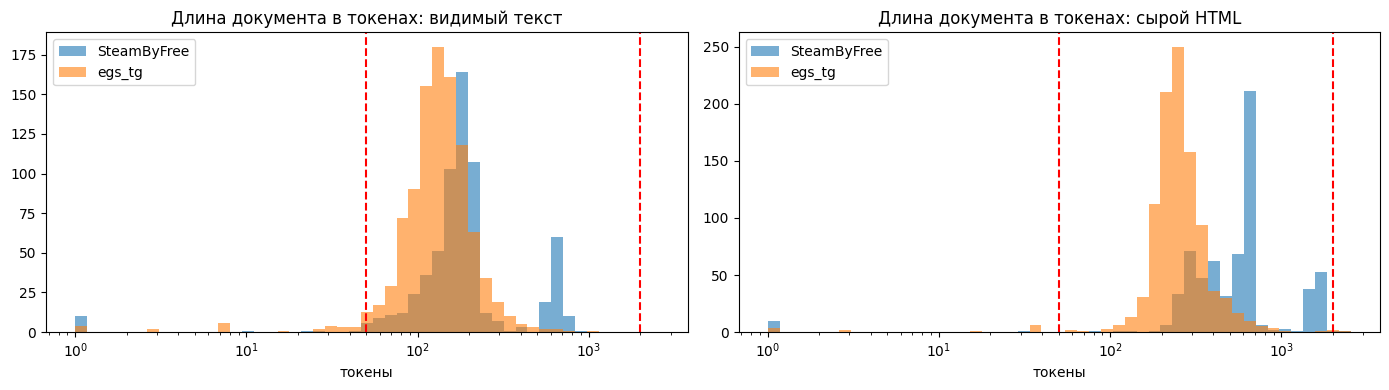

tok_text | перцентили 5/25/50/75/95: [ 64 112 150 189 594] | < 50: 50 | > 2000: 0
tok_raw | перцентили 5/25/50/75/95: [ 167  231  294  542 1535] | < 50: 24 | > 2000: 4


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
bins = np.logspace(0, np.log10(df.tok_raw.max() + 1), 50)
for ax, col, title in [(axes[0], 'tok_text', 'видимый текст'), (axes[1], 'tok_raw', 'сырой HTML')]:
    for src, g in df.groupby('source'):
        ax.hist(g[col].clip(lower=1), bins=bins, alpha=0.6, label=src)
    ax.axvline(50, color='red', ls='--'); ax.axvline(2000, color='red', ls='--')
    ax.set_xscale('log'); ax.set_title(f'Длина документа в токенах: {title}'); ax.set_xlabel('токены'); ax.legend()
plt.tight_layout(); plt.show()

for col in ['tok_text', 'tok_raw']:
    print(col, '| перцентили 5/25/50/75/95:', np.percentile(df[col], [5, 25, 50, 75, 95]).round().astype(int),
          '| < 50:', (df[col] < 50).sum(), '| > 2000:', (df[col] > 2000).sum())

In [7]:
short = df[df.tok_text < 50].sort_values('tok_text')
print('коротких (< 50 токенов текста):', len(short))
short[['doc_id', 'tok_text', 'media', 'text']].head(12)

коротких (< 50 токенов текста): 50


,doc_id,tok_text,media,text
3,egs_tg/11050,0,[],
564,egs_tg/10268,0,[poll],
956,egs_tg/9761,0,[poll],
1004,SteamByFree/19830,0,[],
1644,SteamByFree/17658,0,[],
1097,SteamByFree/19493,0,[],
1151,SteamByFree/19312,0,[],
1050,SteamByFree/19662,0,[],
1215,SteamByFree/19089,0,[],
1247,SteamByFree/18985,0,[],


In [8]:
df.sort_values('tok_raw', ascending=False)[['doc_id', 'tok_raw', 'tok_text', 'text']].head(5)

,doc_id,tok_raw,tok_text,text
132,egs_tg/10867,2546,1026,Главные игровые анонсы и трейлеры с презентации\n \nGamescom Opening Night Live 2026:\n• главный анонс вечера — \nре...
1404,SteamByFree/18471,2328,305,"😎\n На топовые игры завезли скидки до 98%! \nВ \nIGM.GG\n завезли ключи на игры, которые висят у тебя в вишлисте, а ..."
1143,SteamByFree/19337,2148,281,"Bodycam, Fallout, Atomic Heart и море других игр получили скидки до 98% на \nIGM.GG\n — все дешевле чем в Steam и до..."
438,egs_tg/10436,2128,292,⚡️\n \nВ EGS бесплатно раздают 16 DLC и месяц Discord Nitro\nВесь список:\n▫️\nAsphalt Legends - A set of decals\n▫️...
426,egs_tg/10449,1854,668,Главные анонсы Summer Game Fest 2026 \n🎮\n🟠\n Resident Evil: Code Veronica Remake — 2027 год\n🟠\n Final Fantasy VII ...


### 2.2 Мусор в тексте

Делю текст по пробелам и смотрю что за токены: эмодзи, цифры, спецсимволы, ссылки, упоминания, хэштеги. Ещё считаю сколько места занимает html, сколько ссылок, сколько эмодзи-цифр типо 5️⃣0️⃣ и какие строчки чаще всего стоят в конце постов.

In [9]:
EMOJI = re.compile('[\U0001F000-\U0001FAFF\u2600-\u27BF\u2B00-\u2BFF\uFE0F\u20E3\u200D]')

def token_class(tok):
    if re.match(r'(https?://|www\.|t\.me/)', tok, re.I): return 'url'
    if tok.startswith('@'): return 'mention'
    if tok.startswith('#'): return 'hashtag'
    if EMOJI.search(tok) and not re.search(r'[A-Za-zА-Яа-яЁё]', tok): return 'emoji'
    if re.fullmatch(r'[\d.,:%$₽€+\-–/]+', tok) and re.search(r'\d', tok): return 'number'
    if not re.search(r'\w', tok): return 'special'
    return 'word'

rows = []
for src, g in df.groupby('source'):
    c = collections.Counter(token_class(t) for txt in g.text for t in txt.split())
    total = sum(c.values())
    row = {k: round(100 * c[k] / total, 1) for k in ['word', 'number', 'emoji', 'special', 'url', 'mention', 'hashtag']}
    row['html_markup_%'] = round(100 * (1 - g.text.str.len().sum() / g.raw_html.str.len().sum()), 1)
    row['links_in_html'] = int(g.n_links.sum())
    row['keycap_digits'] = int(g.text.str.count('\u20E3').sum())
    rows.append(pd.Series(row, name=src))
pd.DataFrame(rows)

,word,number,emoji,special,url,mention,hashtag,html_markup_%,links_in_html,keycap_digits
SteamByFree,71.5,10.7,6.3,11.4,0.0,0.0,0.0,74.0,1979.0,574.0
egs_tg,89.0,4.6,3.2,3.2,0.0,0.0,0.0,54.5,1108.0,9.0


In [10]:
last_line = df.text.map(lambda t: t.strip().split('\n')[-1].strip() if t.strip() else '<пусто>')
print('самые частые последние строки постов:')
print(last_line.groupby(df.source).value_counts().groupby(level=0).head(3))
print()
print('служебные посты (pinned):', df.text.str.contains('pinned').sum())
print('реклама (erid):', df.text.str.contains('erid').sum())
print('розыгрыши:', df.text.str.contains('РОЗЫГРЫШ|розыгрыш').sum())
print('пример keycap-скидки:', df[df.text.str.contains('получила скидку')].text.iloc[0][:120])

самые частые последние строки постов:
source       text                  
SteamByFree  🎮                         611
             <пусто>                    10
             !                           1
egs_tg       Epic Games Store          954
             <пусто>                     4
             pinned Deleted message      3
Name: count, dtype: int64

служебные посты (pinned): 7
реклама (erid): 1
розыгрыши: 12
пример keycap-скидки: 👍
 Один из лучших сплитскринов — 
A Way Out получила скидку
7️⃣
0️⃣
A Way Out - это уникальное коллективное приключение,


Ссылок в тексте почти ноль, потому что они спрятаны в тегах a href, а в тексте остаётся только слово. Зато в html ссылок больше 3 тысяч, и html вообще занимает больше половины всех символов.

### 2.3 Дубли

Точные дубли ищу по тексту без регистра, ссылок и знаков препинания. Почти-дубли через MinHash по кускам из 5 слов, пробую три порога. Ничего не удаляю, просто считаю.

In [11]:
def norm(t):
    t = re.sub(r'https?://\S+', ' ', t.lower())
    return re.sub(r'\s+', ' ', re.sub(r'[^\w\s]', ' ', t)).strip()

df['norm'] = df.text.map(norm)
nonempty = df[df.norm.str.len() > 0]
exact = nonempty.groupby('norm').doc_id.apply(list)
exact = exact[exact.map(len) > 1]
print('точных дублей: групп', len(exact), '| документов', exact.map(len).sum())
for ids in exact.head(5):
    print('  ', ids, '|', df.set_index('doc_id').loc[ids[0], 'text'][:70].replace('\n', ' '))

def minhash(t):
    m = MinHash(num_perm=128, seed=1)
    w = t.split()
    for i in range(max(1, len(w) - 4)):
        m.update(' '.join(w[i:i + 5]).encode())
    return m

mhs = {r.doc_id: minhash(r.norm) for r in nonempty.itertuples() if len(r.norm.split()) >= 5}
dup_rows, dup_pairs = [], {}
for thr in [0.5, 0.7, 0.9]:
    lsh = MinHashLSH(threshold=thr, num_perm=128)
    for k, m in mhs.items():
        lsh.insert(k, m)
    pairs = {tuple(sorted((k, o))) for k, m in mhs.items() for o in lsh.query(m) if o != k}
    dup_pairs[thr] = pairs
    dup_rows.append({'threshold': thr, 'pairs': len(pairs), 'docs_in_pairs': len({d for p in pairs for d in p}),
                     'cross_source_pairs': sum(a.split('/')[0] != b.split('/')[0] for a, b in pairs)})
pd.DataFrame(dup_rows)

точных дублей: групп 8 | документов 18
   ['SteamByFree/18887', 'SteamByFree/18885'] | 6️⃣  GTA VI СЛИЛИ!  В сеть просочился минутный ролик геймплея за Джейс
   ['egs_tg/9844', 'egs_tg/9705'] | Channel photo updated
   ['egs_tg/10811', 'egs_tg/10421', 'egs_tg/9703'] | Epic Games Store  pinned a photo
   ['egs_tg/10802', 'egs_tg/10294', 'egs_tg/10172'] | Epic Games Store  pinned Deleted message
   ['egs_tg/10536', 'egs_tg/10534'] | ‼️ GTA 6 официально будет стоить $80, а Ultimate Edition — $100  Epic 


,threshold,pairs,docs_in_pairs,cross_source_pairs
0,0.5,13,20,0
1,0.7,12,18,0
2,0.9,11,16,0


In [12]:
by_id = df.set_index('doc_id')
for a, b in sorted(dup_pairs[0.7])[:6]:
    print(a, '|', by_id.loc[a, 'text'][:90].replace('\n', ' '))
    print(b, '|', by_id.loc[b, 'text'][:90].replace('\n', ' '))
    print()

SteamByFree/17809 | ☁️   Во что будете играть на этих выходных? Рассказывайте в комментах  👇 Халявный Steam   
SteamByFree/19404 | ☁️   Во что будете играть на этих выходных? Рассказывайте в комментах  👇 Халявный Steam   

SteamByFree/18885 | 6️⃣   GTA VI СЛИЛИ! В сеть просочился минутный ролик  геймплея  за  Джейсона , а также  ка
SteamByFree/18887 | 6️⃣  GTA VI СЛИЛИ!  В сеть просочился минутный ролик геймплея за Джейсона, а также карта Л

SteamByFree/18894 | ☁️ GTA VI снова слили! Тот же самый хакер слил целых  2 минуты  ночного  геймплея  за  Дже
SteamByFree/18902 | ☁️ GTA VI снова слили!  Тот же самый хакер слил целых 2 минуты ночного геймплея за Джейсон

SteamByFree/19684 | 😱  Сны при температуре 38 —  EARTH DEFENSE FORCE 6 получила скидку 5️⃣ 6️⃣ Живите в будуще
SteamByFree/19719 | 😱  Сны при температуре 38 — EARTH DEFENSE FORCE 6 получила скидку 5️⃣ 6️⃣   Живите в будущ

egs_tg/10172 | Epic Games Store  pinned Deleted message
egs_tg/10294 | Epic Games Store  pinned Deleted mess

Почти-дублей мало и все внутри одного канала: одинаковые посты с вопросом подписчикам, слив GTA два раза подряд, служебные pinned. Между каналами вообще ноль, хотя пишут они часто про одно и то же. Скорее всего это просто пересказы одной новости разными словами, MinHash такое не видит. Проверил через TF-IDF, вот самые похожие пары из разных каналов:

In [13]:
content = df[df.tok_text >= 20].reset_index(drop=True)
tfidf_dup = TfidfVectorizer(min_df=2, token_pattern=r'(?u)\b[а-яёa-z][а-яёa-z0-9]{2,}\b').fit(content.norm)
E = tfidf_dup.transform(content[content.source == 'egs_tg'].norm)
S_ = tfidf_dup.transform(content[content.source == 'SteamByFree'].norm)
sim = cosine_similarity(E, S_)
egs_ids = content[content.source == 'egs_tg'].doc_id.values
st_ids = content[content.source == 'SteamByFree'].doc_id.values
top = np.dstack(np.unravel_index(np.argsort(-sim.ravel())[:5], sim.shape))[0]
for i, j in top:
    print(f'cos={sim[i, j]:.2f}')
    print('  ', egs_ids[i], '|', by_id.loc[egs_ids[i], 'text'][:110].replace('\n', ' '))
    print('  ', st_ids[j], '|', by_id.loc[st_ids[j], 'text'][:110].replace('\n', ' '))

cos=0.65
   egs_tg/10976 | ⚡️   Travis Scott, Metro Boomin, Future и другие тизерят появление в GTA VI Сразу несколько артистов опубликов
   SteamByFree/19551 | ☁️  Это мы слушаем —  Дропнули плейлист с треками из GTA VI! Rockstar  выпустила  плейлист с 27  треками и ано
cos=0.60
   egs_tg/10391 | ⚡️   Сегодня отмечается Всемирный день видеоигр Также 24 мая проходит Всемирный день шизофрении и День душнилы
   SteamByFree/19107 | ☁️  Отмечаем —  Сегодня празднуем Всемирный день геймера! Скидываем и поздравляем братишек Халявный Steam   🎮
cos=0.57
   egs_tg/10586 | 🎁  Новая халява в Epic Games Store I Have No Mouth, and I Must Scream   – Культовый психологический хоррор по 
   SteamByFree/17798 | ☁️  Ну это можно забрать —  Epic Games раздают сразу две игры! На этот раз  забираем : 🔘 I Have No Mouth, and 
cos=0.56
   egs_tg/10684 | ❗️ ОФИЦИАЛЬНО: Fallout 5 уже в разработке Bethesda подтвердила, что Fallout 5 находится в разработке. Также в 
   SteamByFree/18122 | ☁️   Bethesda анонсирова

### 2.4 Кластеры

TF-IDF и KMeans на 8 кластеров, смотрю какие слова главные и из какого канала посты.

In [14]:
STOP = set("""
и в во не что он на я с со как а то все она так его но да ты к у же вы за бы по только ее мне
было вот от меня еще нет о из ему теперь когда даже ну вдруг ли если уже или ни быть был него
до вас нибудь опять уж вам ведь там потом себя ничего ей может они тут где есть надо ней для
мы тебя их чем была сам чтобы без будто чего раз тоже себе под будет ж тогда кто этот того потому
этого какой совсем ним здесь этом один почти мой тем нее сейчас были куда зачем всех никогда
можно при наконец два об другой хоть после над больше тот через эти нас про всего них какая
много разве три эту моя впрочем хорошо свою этой перед иногда лучше чуть том нельзя такой им
более всегда конечно всю между это также которые который которая ещё игры игра игру игре
""".split())

X = nonempty[nonempty.tok_text >= 20]
tfidf = TfidfVectorizer(max_features=20000, min_df=3, max_df=0.5,
                        token_pattern=r'(?u)\b[а-яёa-z][а-яёa-z0-9]{2,}\b', stop_words=list(STOP))
M = tfidf.fit_transform(X.norm)
km = KMeans(n_clusters=8, n_init=10, random_state=42).fit(M)
terms = np.array(tfidf.get_feature_names_out())
df['cluster'] = pd.Series(km.labels_, index=X.index).reindex(df.index)
clusters = pd.DataFrame([{
    'cluster': c,
    'docs': int((km.labels_ == c).sum()),
    'egs_tg': int(((km.labels_ == c) & (X.source == 'egs_tg').values).sum()),
    'SteamByFree': int(((km.labels_ == c) & (X.source == 'SteamByFree').values).sum()),
    'top_terms': ', '.join(terms[np.argsort(-km.cluster_centers_[c])[:10]]),
} for c in range(8)]).set_index('cluster')
clusters

,docs,egs_tg,SteamByFree,top_terms
cluster,,,,
0,64,52,12,"resident, evil, requiem, veronica, capcom, code, года, серии, леона, леон"
1,258,0,258,"покупаем, скидку, акция, получила, продлится, халявный, steam, августа, сентября, июля"
2,476,357,119,"steam, valve, млн, халявный, ubisoft, игр, россии, игроков, тысяч, онлайн"
3,85,74,11,"rtx, nvidia, цены, dlss, памяти, видеокарты, видеокарт, года, amd, могут"
4,144,116,28,"gta, rockstar, ps5, take, слив, релиза, two, auto, grand, theft"
5,368,262,106,"года, забрать, steam, халява, the, лет, бесплатно, релиз, халявный, egs"
6,139,124,15,"sony, playstation, xbox, windows, microsoft, ps5, god, war, могут, game"
7,92,2,90,"рублей, симулятор, рубля, экшен, инструкцией, воспользуйтесь, какие, недоступны, нашей, пишите"


In [15]:
CLUSTER_NAMES = {
    0: 'Resident Evil и Capcom',
    1: 'скидки Steam (шаблонные посты)',
    2: 'Steam, Valve и индустрия в цифрах',
    3: 'железо: NVIDIA, видеокарты, цены на память',
    4: 'GTA 6 и Rockstar',
    5: 'раздачи и бесплатные игры',
    6: 'платформы: Sony, PlayStation, Xbox, Microsoft',
    7: 'подборки со скидками в рублях',
}
clusters.insert(0, 'name', clusters.index.map(CLUSTER_NAMES))
clusters[['name', 'docs', 'egs_tg', 'SteamByFree']]

,name,docs,egs_tg,SteamByFree
cluster,,,,
0,Resident Evil и Capcom,64,52,12
1,скидки Steam (шаблонные посты),258,0,258
2,"Steam, Valve и индустрия в цифрах",476,357,119
3,"железо: NVIDIA, видеокарты, цены на память",85,74,11
4,GTA 6 и Rockstar,144,116,28
5,раздачи и бесплатные игры,368,262,106
6,"платформы: Sony, PlayStation, Xbox, Microsoft",139,124,15
7,подборки со скидками в рублях,92,2,90


### 2.5 Выводы по EDA

Размер постов. Посты короткие: медиана 134 токена в egs_tg и 177 в SteamByFree, половина постов от 112 до 189 токенов, 90% от 64 до 594. Почти любой пост влезает в один чанк целиком. С html посты в 2-3 раза длиннее. В SteamByFree разброс больше (std 175 против 77), там есть подборки на 10 игр. Коротких меньше 50 токенов 50 штук, это в основном картинки, опросы и служебка без текста. Длиннее 2000 токенов по тексту нет вообще, с html таких 4: дайджест с Gamescom, список из 16 DLC и две рекламы IGM.GG, где текста 300 токенов а html 2300.

Что за шум. Html (больше половины символов), подпись в конце почти каждого поста (Epic Games Store в 95% постов egs_tg и строчка с 🎮 в SteamByFree), эмодзи, служебные посты, реклама, розыгрыши, описания игр скопированные из Steam. Рекламу с пометкой erid нашёл только одну, но есть и без пометки (IGM.GG), так что по простому правилу её не отловить. Ещё одна и та же игра бывает на скидке много раз с разными ценами, а один раз в двух постах про одну и ту же акцию цены вообще разные. Дублей мало, а вот одна новость пересказанная в двух каналах встречается часто.

Кластеры. Resident Evil и Capcom, скидки в Steam, Steam и индустрия в цифрах, железо и видеокарты, GTA 6, раздачи, Sony, Xbox и Microsoft, подборки скидок в рублях. Новости почти все из egs_tg, скидки почти все из SteamByFree.

Какие будут проблемы с чанкингом и поиском. Подпись одинаковая у сотен постов, из-за неё поиск будет считать похожими посты которые вообще не связаны. Эмодзи нельзя просто взять и удалить, у скидок цифра записана только эмодзи. Посты про скидки почти одинаковые, поиск будет путать игры и акции, особенно если игра есть в 10 постах. Одна новость из двух каналов будет занимать сразу два места в топе. Посты короткие, мелко резать их смысла нет, а вот подборки на 10 игр наоборот лучше резать по пунктам.

## 3. Золотой набор

### 3.1 Как генерил

Вопросы генерил через Claude Sonnet 4.6 (claude-sonnet-4-6) по API. Temperature 0.7 для генерации вопросов, 0 для baseline и судьи. Все ответы модели сохраняю в data/cache, поэтому если перезапустить ноутбук новых запросов не будет.

Сгенерил с запасом, примерно в полтора раза больше чем надо, потом отбирал руками. Для каждого типа по своему:
- фактические: даю один пост, модель пишет вопрос, короткий ответ и цитату откуда ответ;
- составные: даю два поста которые похожи по TF-IDF (cos от 0.25 до 0.6, чтобы не дубли) и между ними минимум 3 дня, вопрос должен быть такой чтобы нужны были оба поста;
- абстрактные: даю 14 постов из одного кластера, вопрос про тенденцию;
- негативные: даю заголовки всех постов и прошу вопросы на которые в них ответа нет. Половина про то что в корпусе есть но без нужной детали, половина про то чего нет вообще.

Релевантные посты записываю в relevant_doc_ids и ещё сохраняю цитаты, чтобы в КТ2 после нарезки на чанки понять какой чанк правильный.

In [16]:
GEN_MODEL = 'claude-sonnet-4-6'
GEN_TEMPERATURE = 0.7
_client = None

def get_client():
    global _client
    if _client is None:
        _client = anthropic.Anthropic()
    return _client

def ask(prompt, cache_key, max_tokens=2000, temperature=GEN_TEMPERATURE):
    path = CACHE / f'{cache_key}.json'
    if path.exists():
        return json.loads(path.read_text(encoding='utf-8'))
    r = get_client().messages.create(model=GEN_MODEL, max_tokens=max_tokens, temperature=temperature,
                                     messages=[{'role': 'user', 'content': prompt}])
    text = r.content[0].text
    out = {'raw': text, 'usage': [r.usage.input_tokens, r.usage.output_tokens]}
    try:
        out['json'] = json.loads(text[text.index('{'): text.rindex('}') + 1])
    except ValueError:
        out['json'] = None
    path.write_text(json.dumps(out, ensure_ascii=False, indent=1), encoding='utf-8')
    return out

In [17]:
FACTUAL_PROMPT = '''Ты помогаешь собрать тестовый набор вопросов для поисковой системы по постам из Telegram-каналов про игры.
Ниже один пост. Придумай ОДИН вопрос, на который можно точно ответить только по этому посту.
Требования:
- вопрос понятен без поста: явно называй игру, компанию или событие, не пиши "в посте" или "в этой новости";
- ответ короткий и конкретный (число, дата, название, факт) и прямо следует из текста;
- не копируй формулировки поста дословно, спроси так, как спросил бы живой человек;
- evidence: дословная цитата из поста (1-2 предложения), где содержится ответ.
Верни только JSON: {"question": "...", "answer": "...", "evidence": "..."}

Пост:
{post}'''

COMPOSITE_PROMPT = '''Ты помогаешь собрать тестовый набор вопросов для поисковой системы по постам из Telegram-каналов про игры.
Ниже два поста. Придумай ОДИН вопрос, для ответа на который нужна информация из ОБОИХ постов сразу: связать события, сравнить цифры, объединить факты. По одному посту ответить должно быть нельзя.
Если осмысленно связать посты нельзя, верни {"skip": true}.
Требования:
- вопрос понятен без постов, называй игры и компании явно;
- answer: короткий ответ, который объединяет факты из обоих постов;
- evidence_1 и evidence_2: дословные цитаты из первого и второго поста.
Верни только JSON: {"question": "...", "answer": "...", "evidence_1": "...", "evidence_2": "..."}

Пост 1:
{post1}

Пост 2:
{post2}'''

In [18]:
ABSTRACT_PROMPT = '''Ты помогаешь собрать тестовый набор вопросов для поисковой системы по постам из Telegram-каналов про игры.
Ниже посты на одну тему. Придумай 3 обобщающих вопроса о теме, тенденции или закономерности, которая прослеживается сразу в нескольких постах. У вопроса не должно быть ответа в одном конкретном месте, ответ собирается из нескольких постов.
Для каждого вопроса дай answer (2-4 предложения) и relevant_ids: id постов, на которых основан ответ, минимум 3.
Верни только JSON: {"questions": [{"question": "...", "answer": "...", "relevant_ids": ["..."]}]}

Посты:
{posts}'''

NEGATIVE_PROMPT = '''Ты помогаешь собрать тестовый набор вопросов для поисковой системы по постам из двух Telegram-каналов про игры (декабрь 2025 - сентябрь 2026).
Ниже первые строки (заголовки) всех постов базы. Придумай 16 вопросов, на которые в этой базе ответа НЕТ, но которые правдоподобно задал бы пользователь такой системы:
- 8 вопросов "near": про игры, компании или события, которые в заголовках встречаются, но про деталь, которой там явно нет;
- 8 вопросов "far": на ту же тематику (игры, железо, магазины, скидки, индустрия), но про то, чего в базе нет вообще.
Только фактические вопросы, без мнений и прогнозов на будущее.
Верни только JSON: {"questions": [{"question": "...", "kind": "near", "why_no_answer": "..."}]}

Заголовки:
{titles}'''

### 3.2 Какие посты даю модели

Модели отдаю текст без тегов и без подписи канала, а то она начинает спрашивать про подпись. Сам корпус при этом не трогаю. Служебку, рекламу и посты короче 40 слов не беру.

In [19]:
SIGNATURES = {'Epic Games Store', '🎮'}

def clean_for_prompt(t):
    lines = [l.strip() for l in t.split('\n')]
    while lines and (not lines[-1] or lines[-1] in SIGNATURES):
        lines.pop()
    return re.sub(r'\n{3,}', '\n\n', '\n'.join(lines)).strip()

df['clean'] = df.text.map(clean_for_prompt)
df['n_words'] = df.clean.str.split().map(len)
service = df.clean.str.contains(r'pinned|erid', case=False)
pool = df[(df.n_words >= 40) & ~service].copy()
pool['is_deal'] = (pool.source == 'SteamByFree') & pool.clean.str.contains('получила скидку|скидк', case=False)
print('пул:', len(pool))
pool.groupby(['source', 'is_deal']).size()

пул: 1110


source       is_deal
SteamByFree  False      171
             True       344
egs_tg       False      595
dtype: int64

In [20]:
def post_block(row):
    return f'[{row.doc_id}, {str(row.date)[:10]}]\n{row.clean}'

news = pool[~pool.is_deal]
fact_docs = pd.concat([news[news.source == 'egs_tg'].sample(16, random_state=1),
                       news[news.source == 'SteamByFree'].sample(4, random_state=1),
                       pool[pool.is_deal].sample(4, random_state=1)])

vec = TfidfVectorizer(max_features=20000, min_df=2, token_pattern=r'(?u)\b[а-яёa-z][а-яёa-z0-9]{2,}\b')
Mn = vec.fit_transform(news.clean.str.lower())
S = cosine_similarity(Mn)
dates = pd.to_datetime(news.date).values
ids = news.doc_id.values
used, pairs = set(fact_docs.doc_id), []
order = list(range(len(news)))
random.Random(42).shuffle(order)
for i in order:
    if len(pairs) >= 22:
        break
    if ids[i] in used:
        continue
    cands = [j for j in np.argsort(-S[i]) if j != i and 0.25 <= S[i, j] <= 0.6 and ids[j] not in used
             and abs((dates[i] - dates[j]) / np.timedelta64(1, 'D')) >= 3]
    if cands:
        j = cands[0]
        pairs.append((ids[i], ids[j], round(float(S[i, j]), 2)))
        used.update([ids[i], ids[j]])
print('пар для составных:', len(pairs), '| из них межканальных:', sum(a.split('/')[0] != b.split('/')[0] for a, b, _ in pairs))

km_pool = KMeans(n_clusters=8, n_init=10, random_state=42).fit(vec.transform(pool.clean.str.lower()))
pool['gen_cluster'] = km_pool.labels_
sizes = pool.gen_cluster.value_counts()
abstract_clusters = [c for c in sizes.index if sizes[c] >= 30][:5]
print('кластеры для абстрактных вопросов:', abstract_clusters)

пар для составных: 22 | из них межканальных: 5
кластеры для абстрактных вопросов: [1, 5, 2, 3, 7]


### 3.3 Генерация

In [21]:
pool_by_id = pool.set_index('doc_id', drop=False)
jobs = []
for r in fact_docs.itertuples():
    jobs.append(('factual', r.doc_id.replace('/', '_'), FACTUAL_PROMPT.replace('{post}', post_block(r)), [r.doc_id]))
for a, b, s in pairs:
    p = COMPOSITE_PROMPT.replace('{post1}', post_block(pool_by_id.loc[a])).replace('{post2}', post_block(pool_by_id.loc[b]))
    jobs.append(('composite', a.replace('/', '_') + '__' + b.replace('/', '_'), p, [a, b]))
for c in abstract_clusters:
    sub = pool[pool.gen_cluster == c].sample(14, random_state=c)
    posts = '\n\n'.join(post_block(r)[:900] for r in sub.itertuples())
    jobs.append(('abstract', f'cluster{c}', ABSTRACT_PROMPT.replace('{posts}', posts), list(sub.doc_id)))
titles = '\n'.join(sorted({t.split('\n')[0][:110] for t in df.clean if t}))
jobs.append(('negative', 'negatives', NEGATIVE_PROMPT.replace('{titles}', titles), []))

def run_job(job):
    kind, key, prompt, docs = job
    return kind, key, docs, ask(prompt, f'{kind}__{key}', max_tokens=3000 if kind in ('abstract', 'negative') else 1200)

with ThreadPoolExecutor(8) as ex:
    results = list(ex.map(run_job, jobs))

cands = []
for kind, key, docs, out in results:
    j = out['json']
    if kind == 'factual':
        cands.append({'type': 'factual', 'question': j['question'], 'answer': j['answer'], 'relevant_doc_ids': docs, 'evidence': [j['evidence']]})
    elif kind == 'composite':
        if j.get('skip'):
            print('модель отказалась связывать пару:', key)
            continue
        cands.append({'type': 'composite', 'question': j['question'], 'answer': j['answer'], 'relevant_doc_ids': docs, 'evidence': [j['evidence_1'], j['evidence_2']]})
    elif kind == 'abstract':
        for q in j['questions']:
            cands.append({'type': 'abstract', 'question': q['question'], 'answer': q['answer'], 'relevant_doc_ids': q['relevant_ids'], 'evidence': [], 'cluster': key})
    else:
        for q in j['questions']:
            cands.append({'type': 'negative', 'question': q['question'], 'answer': 'В корпусе нет ответа на этот вопрос',
                          'relevant_doc_ids': [], 'evidence': [], 'neg_kind': q['kind'], 'why_no_answer': q['why_no_answer']})
for i, c in enumerate(cands):
    c['cand_id'] = f'c{i:03d}'
json.dump(cands, open(DATA / 'candidates.json', 'w', encoding='utf-8'), ensure_ascii=False, indent=1)

cand_df = pd.DataFrame(cands)
print('кандидатов:', len(cands))
cand_df.type.value_counts()

модель отказалась связывать пару: egs_tg_10692__SteamByFree_19770
кандидатов: 76


type
factual      24
composite    21
negative     16
abstract     15
Name: count, dtype: int64

In [22]:
cand_df[['cand_id', 'type', 'question', 'answer']]

,cand_id,type,question,answer
0,c000,factual,Какие три игры добавят в PlayStation Plus в январе 2026?,"Need for Speed Unbound, Disney Epic Mickey: Rebrushed и Core Keeper"
1,c001,factual,"Сколько магазинов, ТЦ и небоскрёбов с рабочими лифтами якобы будет в GTA 6 по слухам от бывших сотрудников Rockstar?",Более 700
2,c002,factual,На какой год изначально планировался выход PS6?,2027
3,c003,factual,"Когда, по расчётам фаната GTA 6, изучавшего расположение планет в трейлерах Rockstar, должен выйти третий трейлер игры?",14 мая в 18:00 по МСК
4,c004,factual,Сколько лет уже разрабатывается новый проект Santa Monica Studio под руководством Кори Балрога?,7 лет
...,...,...,...,...
71,c071,negative,Вышло ли обновление для Cyberpunk 2077 с поддержкой нового железа?,В корпусе нет ответа на этот вопрос
72,c072,negative,Сколько стоит видеокарта AMD RX 9070 XT в российских магазинах?,В корпусе нет ответа на этот вопрос
73,c073,negative,Когда стартует летняя распродажа в GOG?,В корпусе нет ответа на этот вопрос
74,c074,negative,Объявила ли Valve дату выхода Steam Deck 2?,В корпусе нет ответа на этот вопрос


### 3.4 Ревью

Прочитал всё что сгенерилось, спорное проверял по корпусу. keep это оставил, edit оставил но поправил, reject выкинул, quota вопрос норм но не влез по количеству.

Со скидками проблема: одна игра бывает на скидке кучу раз, и на вопрос типо до какого числа скидка без даты получается несколько правильных ответов:

In [23]:
for game in ['Dying Light', 'Detroit', 'Metro Exodus', 'Plague Tale', 'Machinarium', 'Beholder 3']:
    print(f'{game:14}', df.text.str.contains(game, case=False).sum(), 'постов')

Dying Light    11 постов
Detroit        7 постов
Metro Exodus   8 постов
Plague Tale    7 постов
Machinarium    3 постов
Beholder 3     2 постов


По негативным: по каждому искал в корпусе про что вопрос и смотрел что нашлось. Вот несколько проверок из-за которых вопросы выкинул:

In [24]:
def grep(pattern, n=2, width=220):
    hits = df[df.text.str.replace('\n', ' ').str.contains(pattern, case=False, regex=True)]
    print(f'/{pattern}/: {len(hits)} постов')
    for d, t in hits.text.head(n).items():
        t = t.replace('\n', ' ')
        m = re.search(pattern, t, re.I)
        print('   ', df.doc_id[d], '|', t[max(0, m.start() - 60): m.start() + width])

grep('PS Store на PS3')
grep('TGA 2025')
grep('Meccha Chameleon.{0,200}кооператив')
grep('Cyberpunk', n=1)
grep('DirectStorage')

/PS Store на PS3/: 1 постов
    egs_tg/10580 | и в виде цифровых ключей. Также компания постепенно закроет PS Store на PS3 и PS Vita — новые покупки станут недоступны, но ранее купленные игры можно будет скачать. Epic Games Store


/TGA 2025/: 1 постов
    egs_tg/9694 | 33 заняла 3-е место в недельном чарте Steam после победы на TGA 2025 и выхода масштабного обновления. Kingdom Come: Deliverance II — 5-е место, а GTA V вернулась в топ-10. Epic Games Store
/Meccha Chameleon.{0,200}кооператив/: 2 постов
    SteamByFree/18035 | 😊  В Meccha Chameleon добавили карту с Древним Египтом Популярный  кооператив получил крупное контентное обновление . В игру добавили  локацию с пирамидой , сделали  динамическое окружение для карты «Пингвиний отель»  и замет
    SteamByFree/17677 | 😨   Разработчики Meccha Chameleon заработали $40 миллионов Два инди-автора создали простенький сетевой кооператив про прятки всего за два месяца . Игра моментально завирусилась в TikTok и среди стримеров,  взлетев в топы Steam и пробив о
/Cyberpunk/: 22 постов
    egs_tg/10997 | щает сохранить собственный визуальный стиль — «Ведьмак 4» и Cyberpunk 2 не должны выглядеть как типичные игры на UE5. А ещё в студии заявили, что релиз Cyberpunk 2077 не б

In [25]:
REVIEW = {
    'c000': ('keep', ''), 'c001': ('keep', ''), 'c002': ('keep', ''), 'c004': ('keep', ''), 'c005': ('keep', ''),
    'c006': ('keep', ''), 'c008': ('keep', ''), 'c010': ('keep', ''), 'c011': ('keep', ''), 'c012': ('keep', ''),
    'c013': ('keep', ''), 'c016': ('keep', ''), 'c018': ('keep', ''), 'c023': ('keep', ''),
    'c017': ('keep', 'Beholder 3 с той же скидкой есть в двух подборках, добавил второй пост в релевантные'),
    'c009': ('reject', 'непонятно без поста: какая утилита Scan? К тому же офтоп, пост не про игры'),
    'c019': ('reject', 'вопрос про внутренний розыгрыш канала, живой пользователь такое у поиска не спросит'),
    'c021': ('reject', 'модель выдумала год: в вопросе летняя распродажа 2025, а пост от июля 2026'),
    'c022': ('reject', 'A Plague Tale есть в 7 постах с разными акциями, без даты у вопроса несколько правильных ответов'),
    'c003': ('quota', 'фанатская теория, а не факт'), 'c007': ('quota', ''), 'c014': ('quota', ''), 'c015': ('quota', ''),
    'c020': ('quota', 'Detroit на скидке в нескольких постах, проще не брать'),
    'c024': ('keep', ''), 'c026': ('keep', ''), 'c027': ('keep', ''), 'c028': ('keep', ''), 'c030': ('keep', ''),
    'c031': ('keep', ''), 'c032': ('keep', ''), 'c033': ('keep', ''), 'c034': ('keep', ''), 'c037': ('keep', ''),
    'c040': ('keep', ''), 'c041': ('keep', ''), 'c044': ('keep', ''),
    'c036': ('edit', 'Dying Light на скидке в 11 постах, добавил привязку к акции до 26 сентября; в отдельном посте у The Beast другая цена (1598 вместо 1507), это отметил в ответе'),
    'c039': ('edit', 'посты считают разное (все игры за 2025 год и релизы июня 2026), исходный ответ сравнивал несравнимое; переформулировал вопрос'),
    'c025': ('reject', 'не составной: модели карт и падение поставок на 30-40% есть в одном посте egs_tg/9699'),
    'c029': ('reject', 'не составной: и тираж 2,5 млн, и план выпускать игру каждый год есть в egs_tg/9930'),
    'c035': ('reject', 'не составной: во втором посте Capcom уже есть все цифры (90, 93 и 95,4%)'),
    'c043': ('reject', 'не составной: A24 и фильм V/H/S: SCP есть в одном посте'),
    'c038': ('reject', 'опять про розыгрыши самого канала'),
    'c042': ('reject', 'связь между постами притянута, в эталонном ответе домыслы про ИИ'),
    'c045': ('keep', ''), 'c048': ('keep', ''), 'c050': ('keep', ''), 'c051': ('keep', ''), 'c052': ('keep', ''),
    'c054': ('keep', ''), 'c056': ('keep', ''), 'c057': ('keep', ''), 'c058': ('keep', ''), 'c059': ('keep', ''),
    'c046': ('reject', 'тема склеена искусственно (оценки Highguard, покупка ПК, Stardew Valley), проверяемого ответа нет'),
    'c047': ('reject', 'слишком общий, под смену эпох подходит полкорпуса'),
    'c049': ('reject', 'ответ домысливает, зачем авторы канала упоминают раздачи'),
    'c053': ('reject', 'размытая формулировка, непонятно, что считать правильным ответом'),
    'c055': ('reject', 'почти дубль c050 про размер скидок'),
    'c060': ('keep', ''), 'c061': ('keep', ''), 'c062': ('keep', ''), 'c065': ('keep', ''), 'c066': ('keep', ''),
    'c067': ('keep', ''), 'c068': ('keep', ''), 'c073': ('keep', ''), 'c074': ('keep', ''), 'c075': ('keep', ''),
    'c064': ('reject', 'ответ в корпусе есть: в SteamByFree/17677 Meccha Chameleon названа сетевым кооперативом про прятки'),
    'c069': ('reject', 'не негативный: в egs_tg/9694 есть победа Clair Obscur на TGA 2025'),
    'c070': ('reject', 'не негативный: в egs_tg/10580 сказано, что Sony закроет PS Store на PS3 и PS Vita'),
    'c071': ('reject', 'модель написала, что Cyberpunk 2077 в базе нет, а он есть в 22 постах'),
    'c063': ('reject', 'странная предпосылка про подписку на DLSS, так никто не спрашивает'),
    'c072': ('quota', 'цена RX 9070 XT в России не найдена, но уверенности нет, не стал брать'),
}
EDITS = {
    'c036': {'question': 'По подборкам скидок в Steam, которые действуют до 26 сентября, насколько оригинальная Dying Light дешевле, чем Dying Light: The Beast?',
             'answer': 'Dying Light стоит 186 рублей (скидка 80%), Dying Light: The Beast 1507 рублей (скидка 50%), то есть оригинал дешевле на 1321 рубль. В отдельном посте про эту же акцию у The Beast указана цена 1598 рублей.'},
    'c039': {'question': 'Какие оценки доли игр в Steam, сделанных с использованием ИИ, приводились по итогам 2025 года и в середине 2026 года?',
             'answer': 'По итогам 2025 года ИИ применялся более чем в половине из 19 000 вышедших в Steam игр. По исследованию середины 2026 года с ИИ сделан 31% игр, вышедших в июне (полгода назад было 20%), а к 2028 году доля может вырасти до 59%.'},
}
EXTRA_RELEVANT = {'c017': ['SteamByFree/19718'], 'c036': ['SteamByFree/19514']}

REWRITE_REJECT = {'q34': 'имён собственных в вопросе нет, и при переписывании слово платформы превратилось в платы, смысл сломался'}

In [26]:
cand_df['decision'] = cand_df.cand_id.map(lambda c: REVIEW[c][0])
cand_df['note'] = cand_df.cand_id.map(lambda c: REVIEW[c][1])
pd.crosstab(cand_df.type, cand_df.decision, margins=True)

decision,edit,keep,quota,reject,All
type,,,,,
abstract,0,10,0,5,15
composite,2,13,0,6,21
factual,0,15,5,4,24
negative,0,10,1,5,16
All,2,48,6,20,76


In [27]:
cand_df[cand_df.decision == 'reject'][['cand_id', 'type', 'question', 'note']]

,cand_id,type,question,note
9,c009,factual,Сколько типов вредоносов распознаёт утилита Scan?,"непонятно без поста: какая утилита Scan? К тому же офтоп, пост не про игры"
19,c019,factual,"Сколько Telegram Stars разыгрывается в конкурсе канала SteamByFree, итоги которого подводятся 15 сентября 2026 года?","вопрос про внутренний розыгрыш канала, живой пользователь такое у поиска не спросит"
21,c021,factual,Какая скидка на Metro Exodus во время летней распродажи Steam в 2025 году?,"модель выдумала год: в вопросе летняя распродажа 2025, а пост от июля 2026"
22,c022,factual,До какой даты действует скидка на A Plague Tale: Requiem в Steam?,"A Plague Tale есть в 7 постах с разными акциями, без даты у вопроса несколько правильных ответов"
25,c025,composite,"Какие конкретные модели видеокарт NVIDIA RTX 50-й серии окажутся под угрозой дефицита из-за кризиса на рынке памяти,...",не составной: модели карт и падение поставок на 30-40% есть в одном посте egs_tg/9699
29,c029,composite,Какой тираж продаж ремейка Silent Hill 2 стал основой для планов Konami выпускать игры серии ежегодно?,"не составной: и тираж 2,5 млн, и план выпускать игру каждый год есть в egs_tg/9930"
35,c035,composite,"Как изменилась доля цифровых продаж Capcom с 2024 года по данным из разных источников, и до какого уровня компания п...","не составной: во втором посте Capcom уже есть все цифры (90, 93 и 95,4%)"
38,c038,composite,В розыгрышах канала SteamByFree сколько победителей было предусмотрено в розыгрыше от июля 2026 года и в розыгрыше с...,опять про розыгрыши самого канала
42,c042,composite,"Как инвестиция NVIDIA в Intel на $5 млрд, одобренная ФТК США в декабре 2025 года, соотносится с последующим ростом а...","связь между постами притянута, в эталонном ответе домыслы про ИИ"
43,c043,composite,"Какая кинокомпания присоединилась к созданию фильма V/H/S: SCP по вселенной SCP Foundation, анонсированного в июле 2...",не составной: A24 и фильм V/H/S: SCP есть в одном посте


Что выкинул и почему (самое интересное):
- c021: модель сама придумала год, в вопросе распродажа 2025, а пост от июля 2026;
- c025, c029, c035, c043: типо составные, а на деле весь ответ есть в одном посте;
- c069, c070: типо негативные, а ответ в корпусе есть (PS Store на PS3, Clair Obscur на TGA 2025). Модель видела только заголовки, а нужная инфа была внутри поста;
- c071: модель написала что Cyberpunk 2077 в базе нет, а про него 22 поста;
- c009: какая-то утилита Scan, без поста вообще непонятно о чём, да и пост не про игры.

Два вопроса поправил. В вопрос про цены Dying Light добавил дату акции, потому что игра есть в 11 постах, а у The Beast в двух постах про одну акцию разные цены (1507 и 1598). Вопрос про долю игр с ИИ переписал, там посты считают разное и ответ сравнивал несравнимое.

In [28]:
gold = []
for c in cands:
    decision, note = REVIEW[c['cand_id']]
    if decision not in ('keep', 'edit'):
        continue
    g = dict(c, **EDITS.get(c['cand_id'], {}))
    g['relevant_doc_ids'] = c['relevant_doc_ids'] + EXTRA_RELEVANT.get(c['cand_id'], [])
    g['review_note'] = note
    gold.append(g)
type_order = {'factual': 0, 'composite': 1, 'abstract': 2, 'negative': 3}
gold.sort(key=lambda g: (type_order[g['type']], g['cand_id']))
for i, g in enumerate(gold, 1):
    g['qid'] = f'q{i:02d}'
    g['question_orig'] = g['question']
pd.Series([g['type'] for g in gold]).value_counts()

factual      15
composite    15
abstract     10
negative     10
Name: count, dtype: int64

Осталось 50 вопросов: 15 фактических, 15 составных, 10 абстрактных, 10 негативных.

### 3.5 Разные формулировки

Вопросы от модели получились слишком гладкие, обычные люди так не пишут. Поэтому раскидал стили рандомно (seed 7): 8 с опечатками (16%, опечатки ставлю своей функцией), 8 разговорных, 6 коротких как в поиске, 6 где названия написаны по другому (гта, рокстар, сталкер). Разговорные, короткие и названия переписывает модель. Остальные 22 оставил как были, оригинал лежит в question_orig. Одно переписывание пришлось откатить, видно ниже.

In [29]:
REWRITE = {
    'colloquial': 'Перепиши вопрос так, как его написал бы обычный геймер в чате: разговорно, можно сленг, без официоза. Смысл и важные детали (названия, числа, даты) сохрани. Верни только переписанный вопрос.',
    'short': 'Сократи вопрос до очень короткого запроса, как в поисковой строке, 2-6 слов. Главные названия сохрани. Верни только запрос.',
    'names': 'Перепиши вопрос, поменяв написание имён собственных так, как их часто пишут пользователи: транслитом, сокращением, сленгом или с ошибкой в названии (например: гта, резик, плойка, ведьмак, нвидиа, сони). Остальное оставь как есть. Верни только вопрос.',
}

NEIGH = dict(zip('йцукенгшщзхфывапролджэячсмитьбю', 'цйкуенгшщзхъывапролджэчясмитьбюб'))
def add_typos(text, r, n=2):
    words = text.split(' ')
    cand = [i for i, w in enumerate(words) if len(re.sub(r'[^а-яё]', '', w.lower())) >= 5]
    for i in r.sample(cand, min(n, len(cand))):
        w = words[i]
        pos = [k for k, ch in enumerate(w) if ch.lower() in NEIGH][1:-1]
        if not pos:
            continue
        k = r.choice(pos)
        op = r.choice(['swap', 'drop', 'double', 'neigh'])
        if op == 'swap' and k + 1 < len(w):
            w = w[:k] + w[k + 1] + w[k] + w[k + 2:]
        elif op == 'drop':
            w = w[:k] + w[k + 1:]
        elif op == 'double':
            w = w[:k] + w[k] + w[k:]
        else:
            w = w[:k] + NEIGH[w[k].lower()] + w[k + 1:]
        words[i] = w
    return ' '.join(words)

In [30]:
rng = random.Random(7)
qids = [g['qid'] for g in gold]
rng.shuffle(qids)
style = {q: 'typo' for q in qids[:8]} | {q: 'colloquial' for q in qids[8:16]} | {q: 'short' for q in qids[16:22]} | {q: 'names' for q in qids[22:28]}

for g in gold:
    s = style.get(g['qid'], 'formal')
    g['style'] = s
    if s == 'typo':
        g['question'] = add_typos(g['question_orig'], random.Random(g['qid']))
    elif s in REWRITE:
        out = ask(f"{REWRITE[s]}\n\nВопрос: {g['question_orig']}", f"rewrite__{s}__{g['cand_id']}", max_tokens=300)
        g['question'] = out['raw'].strip().strip('"«»')
    if g['qid'] in REWRITE_REJECT:
        print('откат переписывания', g['qid'], '|', g['question'], '|', REWRITE_REJECT[g['qid']])
        g['question'], g['style'] = g['question_orig'], 'formal'

styled = pd.DataFrame(gold)
styled[styled['style'] != 'formal'][['qid', 'type', 'style', 'question_orig', 'question']]

откат переписывания q34 | Как крупные платы и конторы реагируют на недовольство юзеров своими решениями? | имён собственных в вопросе нет, и при переписывании слово платформы превратилось в платы, смысл сломался


,qid,type,style,question_orig,question
0,q01,factual,colloquial,Какие три игры добавят в PlayStation Plus в январе 2026?,"Эй, кто знает какие 3 игры добавят в PS Plus в январе 2026?"
1,q02,factual,names,"Сколько магазинов, ТЦ и небоскрёбов с рабочими лифтами якобы будет в GTA 6 по слухам от бывших сотрудников Rockstar?","Сколько магазинов, ТЦ и небоскрёбов с рабочими лифтами якобы будет в гта 6 по слухам от бывших сотрудников рокстар?"
7,q08,factual,names,Сколько раз игроки погладили котов в Assassin's Creed Shadows за год?,Сколько раз игроки погладили котов в ассасин кред шэдоус за год?
8,q09,factual,colloquial,Какой аргумент привёл депутат Михаил Иванов в пользу запрета серии GTA в России?,"Чё там депутат Михаил Иванов говорил, когда хотел запретить GTA в России, какой аргумент приводил?"
10,q11,factual,typo,Что Sony запатентовала в своём геймпаде DualSense?,Что Sony запатентовала в свём гейпаде DualSense?
11,q12,factual,typo,Что позволяет делать мод CyberMP для Cyberpunk 2077?,Что поззволяет делтаь мод CyberMP для Cyberpunk 2077?
12,q13,factual,short,Какая скидка на Beholder 3 в подборке игр до 250 рублей в Steam?,Скидка Beholder 3 Steam
14,q15,factual,typo,Сколько стоит Machinarium в рублях во время акции со скидкой 85%?,Сколько стоит Machinarium в рубях во время акции со скидкой 85%?
16,q17,composite,typo,"Как изменилась ситуация с угрозой блокировки игр Electronic Arts (например, The Sims 4 и Battlefield) в России в пер...","Как изменилась ситуация с угрозой блокировки игр Electronic Arts (например, The Sims 4 и Battlefield) в России в пер..."
18,q19,composite,names,"Согласно анонсам Bethesda, какой приоритет имеет TES VI в компании и когда ожидается выход Fallout 5 — до или после ...","Согласно анонсам бесезды, какой приоритет имеет тес 6 в компании и когда ожидается выход фолаут 5 — до или после тес 6?"


In [31]:
pd.crosstab(styled.type, styled['style'])

style,colloquial,formal,names,short,typo
type,,,,,
abstract,2,5,1,0,2
composite,2,7,1,3,2
factual,2,7,2,1,3
negative,2,4,1,2,1


### 3.6 Сплит

70 на 30 со стратификацией по типу, в val и в test есть все типы.

In [32]:
labels = [g['type'] for g in gold]
val, test = train_test_split(gold, test_size=0.3, stratify=labels, random_state=42)
for g in val:
    g['split'] = 'val'
for g in test:
    g['split'] = 'test'
gold_df = pd.DataFrame(gold)
pd.crosstab(gold_df.type, gold_df.split, margins=True)

split,test,val,All
type,,,
abstract,3,7,10
composite,5,10,15
factual,4,11,15
negative,3,7,10
All,15,35,50


### 3.7 Покрытие

Смотрю в какие кластеры из EDA попадают посты из набора.

In [33]:
rel = gold_df.explode('relevant_doc_ids').dropna(subset=['relevant_doc_ids'])
rel_docs = df[df.doc_id.isin(rel.relevant_doc_ids)]
covered = set(rel_docs.cluster.dropna().astype(int))
print('уникальных релевантных документов:', rel_docs.doc_id.nunique(), 'из', len(df))
print('по источникам:', rel_docs.source.value_counts().to_dict())
print('задето кластеров:', len(covered), 'из', len(CLUSTER_NAMES))
in_covered = df.cluster.isin(covered).sum() / df.cluster.notna().sum()
print(f'доля корпуса в задетых кластерах: {in_covered:.0%}')
cov = clusters[['name', 'docs']].copy()
cov['gold_docs'] = rel_docs.cluster.value_counts().reindex(cov.index).fillna(0).astype(int)
cov

уникальных релевантных документов: 90 из 1650
по источникам: {'egs_tg': 53, 'SteamByFree': 37}
задето кластеров: 8 из 8
доля корпуса в задетых кластерах: 100%


,name,docs,gold_docs
cluster,,,
0,Resident Evil и Capcom,64,1
1,скидки Steam (шаблонные посты),258,13
2,"Steam, Valve и индустрия в цифрах",476,14
3,"железо: NVIDIA, видеокарты, цены на память",85,2
4,GTA 6 и Rockstar,144,16
5,раздачи и бесплатные игры,368,13
6,"платформы: Sony, PlayStation, Xbox, Microsoft",139,14
7,подборки со скидками в рублях,92,17


Вопросы попадают во все 8 кластеров и в оба канала, и есть все 4 сценария: ответ в одном посте, ответ из нескольких постов, вопрос про тему целиком и вопрос без ответа. У такой базы спрашивать будут в основном про новости игр и компаний, скидки, раздачи и тренды, это всё покрыто. Не покрыты служебка, реклама и розыгрыши, их никто искать и не будет. Всего в набор попало 90 постов, это около 5% корпуса. Проверять каждый пост и не надо, важнее чтобы были разные типы поиска. Вопросов всего 50, поэтому если метрики у разных вариантов отличаются немного, это скорее ориентир чем точный результат.

In [34]:
json.dump(gold, open(DATA / 'gold_set.json', 'w', encoding='utf-8'), ensure_ascii=False, indent=1)
gold_df[['qid', 'split', 'type', 'style', 'question', 'answer', 'relevant_doc_ids']].head(10)

,qid,split,type,style,question,answer,relevant_doc_ids
0,q01,val,factual,colloquial,"Эй, кто знает какие 3 игры добавят в PS Plus в январе 2026?","Need for Speed Unbound, Disney Epic Mickey: Rebrushed и Core Keeper",[egs_tg/9805]
1,q02,val,factual,names,"Сколько магазинов, ТЦ и небоскрёбов с рабочими лифтами якобы будет в гта 6 по слухам от бывших сотрудников рокстар?",Более 700,[egs_tg/9842]
2,q03,val,factual,formal,На какой год изначально планировался выход PS6?,2027,[egs_tg/9990]
3,q04,val,factual,formal,Сколько лет уже разрабатывается новый проект Santa Monica Studio под руководством Кори Балрога?,7 лет,[egs_tg/9981]
4,q05,val,factual,formal,До какого числа можно бесплатно забрать Bloons TD 6 в Epic Games Store?,До 15 января,[egs_tg/9833]
5,q06,test,factual,formal,Какое новое подразделение создала Electronic Arts для размещения рекламы в играх?,EA Advertising,[egs_tg/10491]
6,q07,val,factual,formal,Сколько часов в месяц пользователи проводят в Roblox по данным аналитика Matthew Ball?,"10,3 млрд часов",[egs_tg/10019]
7,q08,val,factual,names,Сколько раз игроки погладили котов в ассасин кред шэдоус за год?,26 млн раз,[egs_tg/10139]
8,q09,val,factual,colloquial,"Чё там депутат Михаил Иванов говорил, когда хотел запретить GTA в России, какой аргумент приводил?",Некий «мужской стриптиз» в игре,[egs_tg/9869]
9,q10,test,factual,formal,Какую пользовательскую оценку на Metacritic получил шутер Highguard?,2/10,[egs_tg/9919]


## 4. Baseline без RAG

Беру val (35 вопросов) и прошу модель ответить без всякого контекста, temperature 0. Потом та же модель как судья сравнивает ответ с эталоном и ставит correct, partial, incorrect или abstain (отказалась). Для негативных правильно как раз отказаться.

In [35]:
ANSWER_PROMPT = '''Ответь на вопрос про игры и игровую индустрию. Отвечай коротко, по существу.
Если точного ответа не знаешь, так и напиши: "Не знаю".

Вопрос: {q}'''

JUDGE_PROMPT = '''Сравни ответ модели с эталонным ответом на вопрос.
Метки:
- correct: ответ по сути совпадает с эталоном;
- partial: часть ответа верна, но не хватает важного или есть ошибки;
- incorrect: ответ неверный или выдуманный;
- abstain: модель отказалась отвечать или сказала, что не знает.
Верни только JSON: {"label": "...", "comment": "одно предложение"}

Вопрос: {q}
Эталон: {ref}
Ответ модели: {ans}'''

In [36]:
val_q = [g for g in gold if g['split'] == 'val']

def run_baseline(g):
    ans = ask(ANSWER_PROMPT.replace('{q}', g['question']), f"norag__{g['qid']}", max_tokens=600, temperature=0)['raw'].strip()
    ref = 'Ответа нет, правильное поведение: признать, что не знает.' if g['type'] == 'negative' else g['answer']
    j = ask(JUDGE_PROMPT.replace('{q}', g['question_orig']).replace('{ref}', ref).replace('{ans}', ans),
            f"judge_norag__{g['qid']}", max_tokens=300, temperature=0)['json']
    return {'qid': g['qid'], 'type': g['type'], 'style': g['style'], 'question': g['question'],
            'answer_no_rag': ans, 'label': j['label'], 'comment': j['comment']}

with ThreadPoolExecutor(8) as ex:
    base = pd.DataFrame(list(ex.map(run_baseline, val_q)))
base.to_json(DATA / 'baseline_no_rag.json', orient='records', force_ascii=False, indent=1)
pd.crosstab(base.type, base.label, margins=True)

label,abstain,correct,incorrect,partial,All
type,,,,,
abstract,2,0,1,4,7
composite,7,0,3,0,10
factual,9,0,2,0,11
negative,1,2,2,2,7
All,19,2,8,6,35


In [37]:
answerable = base[base.type != 'negative']
negative = base[base.type == 'negative']
summary = pd.Series({
    'вопросов с ответом в корпусе': len(answerable),
    'correct': (answerable.label == 'correct').sum(),
    'partial': (answerable.label == 'partial').sum(),
    'incorrect (выдумал)': (answerable.label == 'incorrect').sum(),
    'abstain (не знаю)': (answerable.label == 'abstain').sum(),
    'негативных вопросов': len(negative),
    'негативные: корректный отказ': negative.label.isin(['abstain', 'correct']).sum(),
    'негативные: ответил по памяти': negative.label.isin(['incorrect', 'partial']).sum(),
})
summary

вопросов с ответом в корпусе     28
correct                           0
partial                           4
incorrect (выдумал)               6
abstain (не знаю)                18
негативных вопросов               7
негативные: корректный отказ      3
негативные: ответил по памяти     4
dtype: int64

In [38]:
base[base.label.isin(['incorrect', 'partial'])][['qid', 'type', 'question', 'answer_no_rag', 'comment']]

,qid,type,question,answer_no_rag,comment
5,q07,factual,Сколько часов в месяц пользователи проводят в Roblox по данным аналитика Matthew Ball?,"По данным аналитика Мэтью Болла, пользователи проводят в Roblox около **1,5 миллиарда часов в месяц** (данные могли ...","Модель назвала 1,5 млрд часов, тогда как правильный ответ — 10,3 млрд часов в месяц."
8,q11,factual,Что Sony запатентовала в свём гейпаде DualSense?,"Sony запатентовала несколько технологий в DualSense, ключевые из которых:\n\n- **Адаптивные триггеры** (L2/R2) — с и...","Модель описала общеизвестные функции DualSense, но не упомянула встроенный NFC для бесконтактной оплаты, который явл..."
13,q18,composite,"Какие изменения в распространении игр планирует Sony к 2028 году, и затронут ли они одиночные игры от внутренних сту...",Sony планирует к 2028 году перевести **50% своих игр на сервисную модель (live-service)**. Однако это касается именн...,"Ответ модели говорит о переходе на live-service модель и подписку PlayStation Plus, тогда как эталон касается отказа..."
16,q24,composite,"Что произошло с ремейком Prince of Persia: The Sands of Time от Ubisoft, и как это связано с увольнениями в Ubisoft ...",Ремейк **Prince of Persia: The Sands of Time** пережил долгую и проблемную разработку. Изначально анонсированный в 2...,Модель не упомянула отмену ремейка Prince of Persia и его связь с увольнениями в Ubisoft Toronto через параллель со ...
18,q26,composite,"Насколько предзаказы GTA VI на PS5 опережают Xbox по данным IGN, и что при этом заявляет директор по стратегии Xbox ...","По данным IGN, предзаказы GTA VI на PS5 опережают Xbox примерно в **соотношении 2:1**.\n\nПри этом директор по страт...",Модель указала неверное соотношение (2:1 вместо 6:1) и неправильно назвала имя директора по стратегии Xbox (Аарон Гр...
21,q31,abstract,"Слушайте, а что вообще происходит с крупными игровыми компаниями и платформами — они реально меняют свои стратегии и...","## Да, реально меняют. Вот ключевые тренды:\n\n**Давление рынка работает:**\n- Xbox/Microsoft после провальных прода...","Ответ содержит ряд верных наблюдений (эксклюзивность Xbox, портирование Sony на PC, проблемы сервисной модели), но у..."
22,q32,abstract,Какие игры-симуляторы выхоидли со скидками в Steam и насколько значительными были эти скидки?,Это слишком широкий вопрос — в Steam регулярно выходят сотни симуляторов со скидками (во время распродаж и не только...,"Модель упомянула Euro Truck Simulator 2 и диапазон скидок 25–75%, что частично совпадает с эталоном, но конкретные д..."
24,q36,abstract,Какие игры появляются в подборках со скдиками нескольок раз на протяжении разных периодов?,"Чаще всего в подборках со скидками (Steam, Humble Bundle, PS Store, Xbox и т.д.) повторяются:\n\n- **GTA V** — появл...","Модель дала общий ответ о популярных играх в распродажах вместо конкретных игр из эталонных подборок (No Man's Sky, ..."
26,q39,abstract,"Чё вообще будет с игровой индустрией когда выйдет GTA 6, как думаете?","## Честный ответ\n\nЭто **мнение/прогноз**, а не факт, но вот что реально вероятно:\n\n- **Продажи других игр просяд...","Модель даёт общие логичные прогнозы, но упускает конкретные детали из эталона: влияние на решение Sony отказаться от..."
27,q40,abstract,С какими трудностями столкнулась рокстар в процессе разработки и продвижения гта 6?,## Трудности Rockstar при разработке GTA 6\n\n**Утечка материалов (сентябрь 2022):**\n- Крупнейшая утечка в истории ...,"Модель верно упоминает утечку материалов, но не знает о пожаре в офисе, переносе релиза с мая на ноябрь 2026 года, к..."


### Нужен ли RAG

Нужен. Из 28 вопросов где ответ в корпусе есть, модель без контекста не ответила правильно ни на один: 18 раз сказала не знаю, 6 раз выдумала, 4 раза частично. Корпус с декабря 2025 по сентябрь 2026, модель эти новости просто не знает. И когда выдумывает, пишет очень уверенно: про Roblox сказала 1,5 млрд часов, а в посте 10,3 млрд, про предзаказы GTA VI сказала 2 к 1, а там в 6 раз. Частично правильно было только на абстрактных, там можно ответить общими словами.

На негативных отказалась в 3 из 7, в остальных ответила по своей памяти. Например требования Stalker 2 или кто делает Silent Hill: Townfall она может и знает правильно, но в корпусе этого нет, а система по базе должна сказать что ответа нет.

Ещё заметил что судья отказ на негативном вопросе ставит то correct, то abstain, поэтому для негативных считаю отказом обе метки. В КТ5 промпт судьи надо будет сделать построже.

## Что получилось в КТ1

- data/corpus_raw.jsonl: сырой корпус, 1650 постов;
- data/gold_set.json: 50 вопросов с ответами, релевантными постами, цитатами, стилем и сплитом 35/15;
- data/candidates.json: все 76 кандидатов и что с ними решил;
- data/baseline_no_rag.json: ответы без RAG и оценки судьи;
- data/cache: ответы модели, по ним ноутбук перезапускается без новых запросов.